# Planning / inference visualization

Visualize the planning probe outputs already written under `results/`, then optionally run one faithful CEM inference trace on a selected cached transition. The trace section uses the same adapter, latent cache, and CEM hyperparameters as the diagnostic scripts.

## 0 · Setup and editable knobs

In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "configs").is_dir() and (p / "planning" / "cem_planner.py").exists():
            return p
        if (p / "diagnosis" / "configs").is_dir():
            return p / "diagnosis"
    raise FileNotFoundError("Could not locate diagnosis/ root")

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"

# ---- editable knobs -------------------------------------------------------
CONFIG_PATH = ROOT / "configs" / "diagnostic_metaworld.yaml"
DATASET = "metaworld"
MODEL = "dino_wm_metaworld"
REGIME = "contact_manipulation"
HORIZON = 3
TRANSITION_INDEX = 0
DEVICE = "cuda"

print("diagnosis root:", ROOT)
print("config:", CONFIG_PATH)

diagnosis root: /home/nhatnc129/nhat.nc/jepa-research/diagnosis
config: /home/nhatnc129/nhat.nc/jepa-research/diagnosis/configs/diagnostic_metaworld.yaml


## 1 · Planning result tables

In [2]:
csv_paths = sorted(RESULTS.glob("*planning*.csv"))
summary_tables = {}
for path in csv_paths:
    try:
        df = pd.read_csv(path)
    except Exception as exc:
        print(f"skip {path.name}: {exc}")
        continue
    summary_tables[path.stem] = df

print(f"loaded {len(summary_tables)} planning CSV files")
for name, df in summary_tables.items():
    print(f"{name:36s} rows={len(df):4d} columns={list(df.columns)}")

if summary_tables:
    display(pd.concat(
        [df.assign(source=name) for name, df in summary_tables.items()],
        ignore_index=True, sort=False,
    ).head(20))

loaded 6 planning CSV files
droid_planning_bounded               rows=   6 columns=['dataset', 'model', 'regime', 'horizon', 'n_planned', 'max_planning_transitions', 'cem_num_samples', 'cem_iterations', 'cem_num_elites', 'action_error', 'action_error_lo', 'action_error_hi', 'cra_eff', 'cra_eff_lo', 'cra_eff_hi', 'action_score', 'd_ref_p95']
droid_planning_safe                  rows=   6 columns=['dataset', 'model', 'regime', 'horizon', 'n_planned', 'max_planning_transitions', 'cem_num_samples', 'cem_iterations', 'cem_num_elites', 'action_error', 'action_error_lo', 'action_error_hi', 'cra_eff', 'cra_eff_lo', 'cra_eff_hi', 'action_score', 'd_ref_p95']
metaworld_planning_jepa              rows=   6 columns=['dataset', 'model', 'regime', 'horizon', 'n_planned', 'max_planning_transitions', 'cem_num_samples', 'cem_iterations', 'cem_num_elites', 'action_error', 'action_error_lo', 'action_error_hi', 'cra_eff', 'cra_eff_lo', 'cra_eff_hi', 'action_score', 'd_ref_p95']
metaworld_planning_metric  

,dataset,model,regime,horizon,n_planned,max_planning_transitions,cem_num_samples,cem_iterations,cem_num_elites,action_error,...,cra_eff,cra_eff_lo,cra_eff_hi,action_score,d_ref_p95,source,arm,beta,s_z,s_g
0,droid,dino_wm_droid,pre_grasp,1,30,30.0,100.0,15.0,10.0,1.015448,...,0.066667,0.000000,0.172414,0.612597,2.621165,droid_planning_bounded,NaN,NaN,NaN,NaN
1,droid,dino_wm_droid,gripper_actuation,1,18,30.0,100.0,15.0,10.0,1.136154,...,0.000000,0.000000,0.000000,0.566546,2.621165,droid_planning_bounded,NaN,NaN,NaN,NaN
2,droid,dino_wm_droid,contact_manipulation,1,30,30.0,100.0,15.0,10.0,1.096276,...,0.100000,0.016129,0.206897,0.581760,2.621165,droid_planning_bounded,NaN,NaN,NaN,NaN
3,droid,dino_wm_droid,pre_grasp,3,30,30.0,100.0,15.0,10.0,1.810569,...,0.033333,0.000000,0.107143,0.309250,2.621165,droid_planning_bounded,NaN,NaN,NaN,NaN
4,droid,dino_wm_droid,gripper_actuation,3,17,30.0,100.0,15.0,10.0,1.847222,...,0.000000,0.000000,0.000000,0.295267,2.621165,droid_planning_bounded,NaN,NaN,NaN,NaN
5,droid,dino_wm_droid,contact_manipulation,3,30,30.0,100.0,15.0,10.0,1.639336,...,0.016667,0.000000,0.048387,0.374577,2.621165,droid_planning_bounded,NaN,NaN,NaN,NaN
6,droid,dino_wm_droid,pre_grasp,1,40,40.0,64.0,15.0,10.0,1.078682,...,0.087500,0.012500,0.179487,0.637186,2.973095,droid_planning_safe,NaN,NaN,NaN,NaN
7,droid,dino_wm_droid,gripper_actuation,1,18,40.0,64.0,15.0,10.0,1.077930,...,0.000000,0.000000,0.000000,0.637438,2.973095,droid_planning_safe,NaN,NaN,NaN,NaN
8,droid,dino_wm_droid,contact_manipulation,1,40,40.0,64.0,15.0,10.0,1.172932,...,0.000000,0.000000,0.000000,0.605484,2.973095,droid_planning_safe,NaN,NaN,NaN,NaN
9,droid,dino_wm_droid,pre_grasp,3,40,40.0,64.0,15.0,10.0,1.627607,...,0.000000,0.000000,0.000000,0.452555,2.973095,droid_planning_safe,NaN,NaN,NaN,NaN


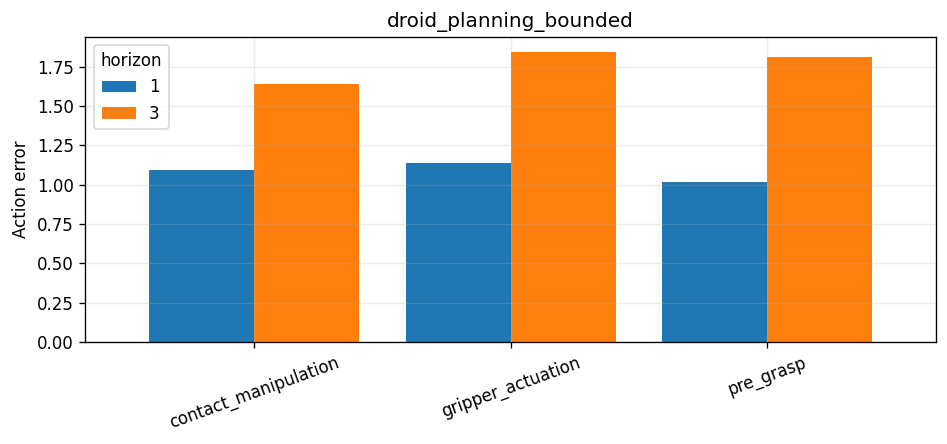

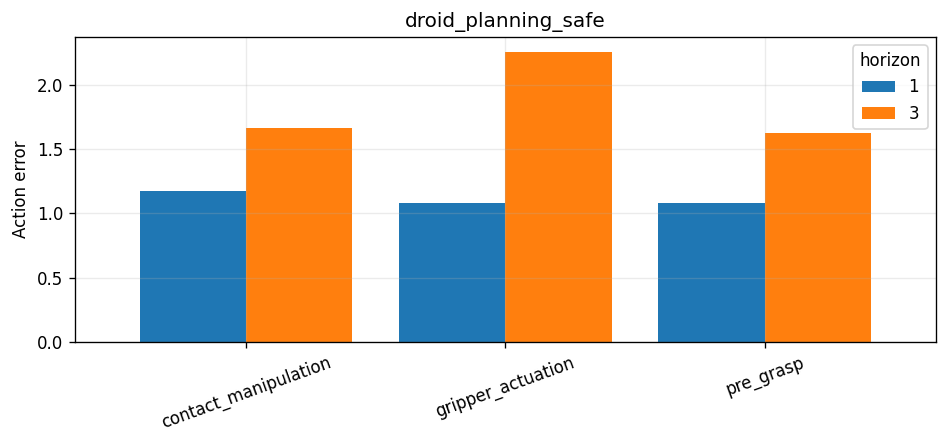

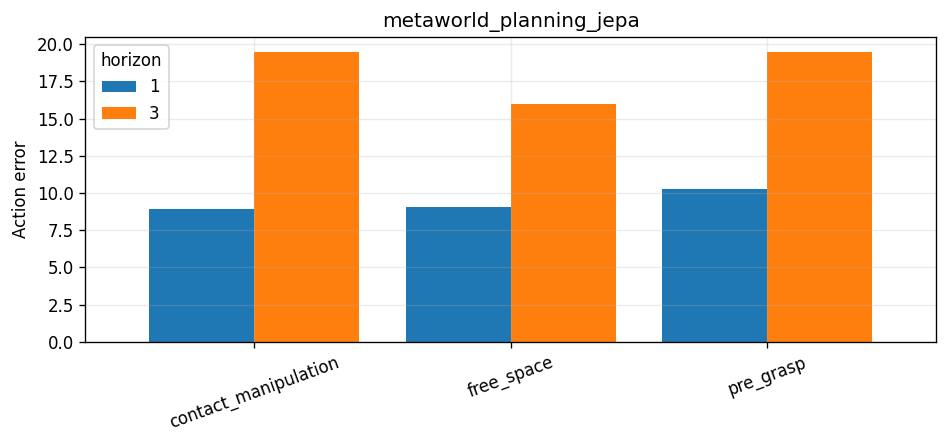

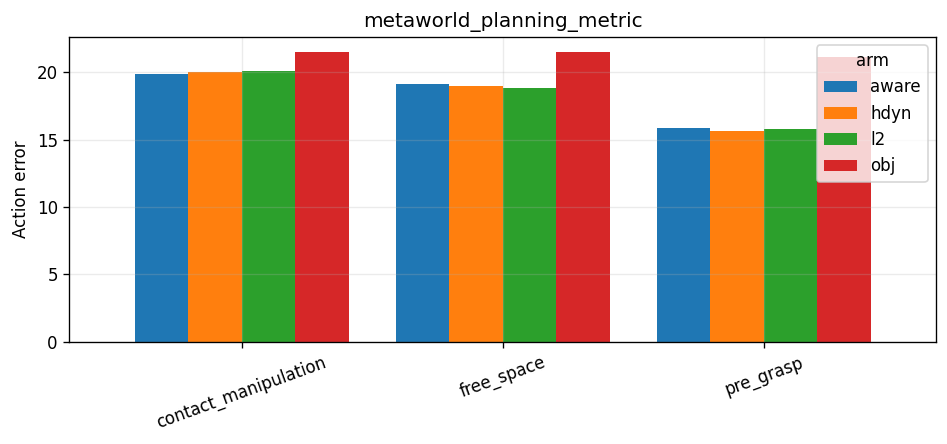

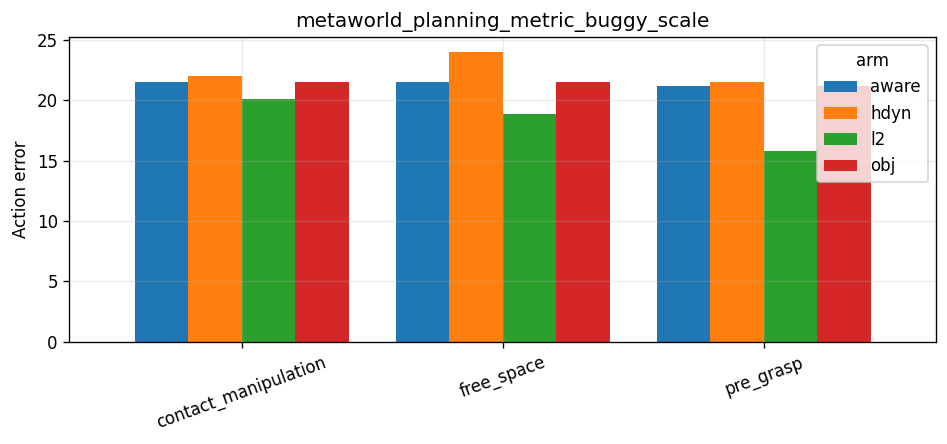

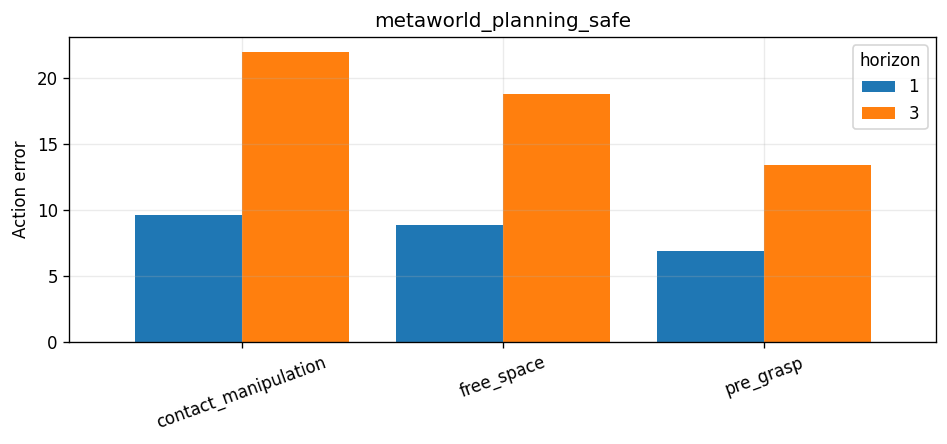

In [3]:
def plot_error_table(name: str, df: pd.DataFrame):
    needed = {"regime", "action_error"}
    if not needed.issubset(df.columns):
        return
    work = df.copy()
    if "arm" in work.columns:
        work = work[~work["arm"].astype(str).str.contains("minus", na=False)]
        hue_col = "arm"
    elif "horizon" in work.columns:
        hue_col = "horizon"
    else:
        hue_col = None

    fig, ax = plt.subplots(figsize=(8, 3.8))
    if hue_col:
        piv = work.pivot_table(index="regime", columns=hue_col, values="action_error", aggfunc="mean")
        piv.plot(kind="bar", ax=ax, width=0.82)
    else:
        vals = work.groupby("regime")["action_error"].mean()
        vals.plot(kind="bar", ax=ax)
    ax.set_title(name)
    ax.set_ylabel("Action error")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

for name, df in summary_tables.items():
    plot_error_table(name, df)

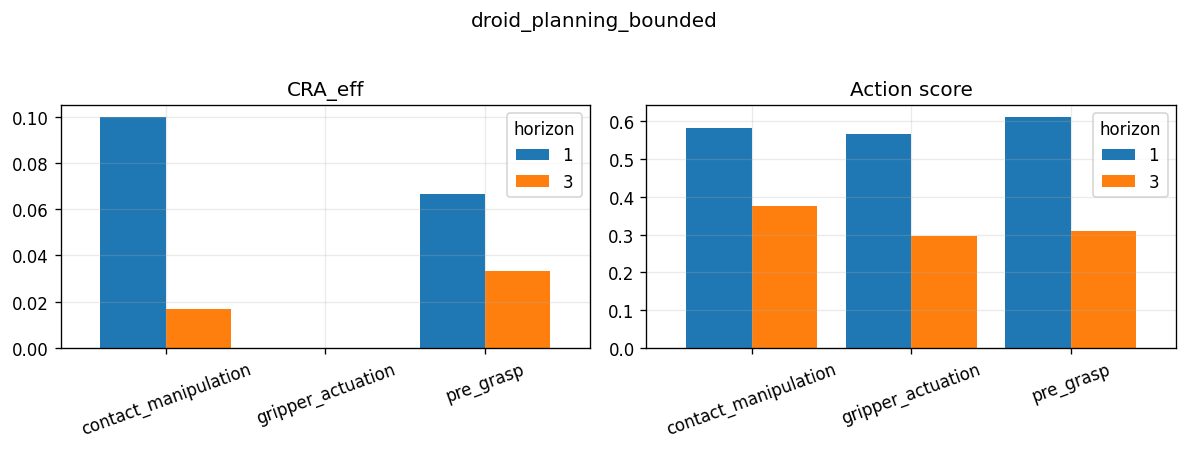

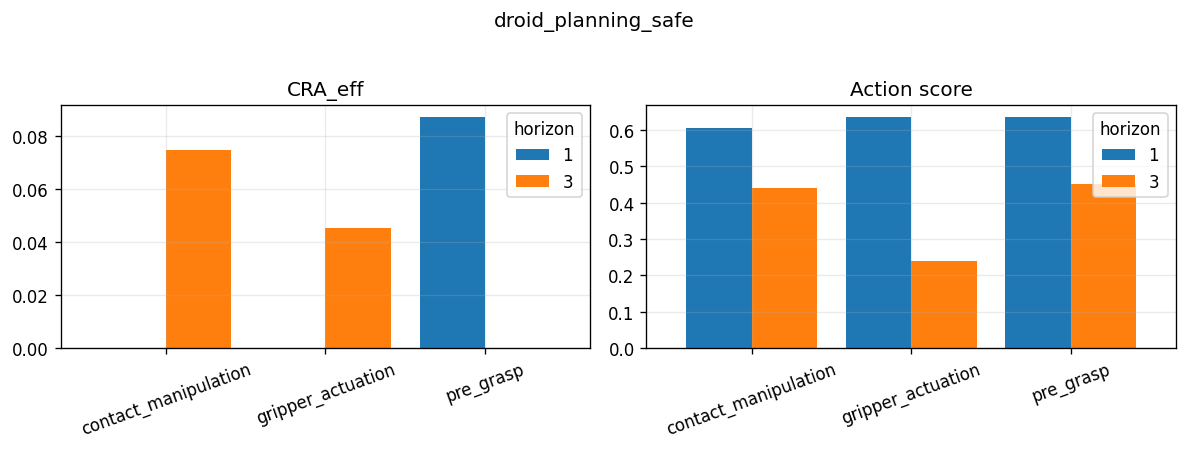

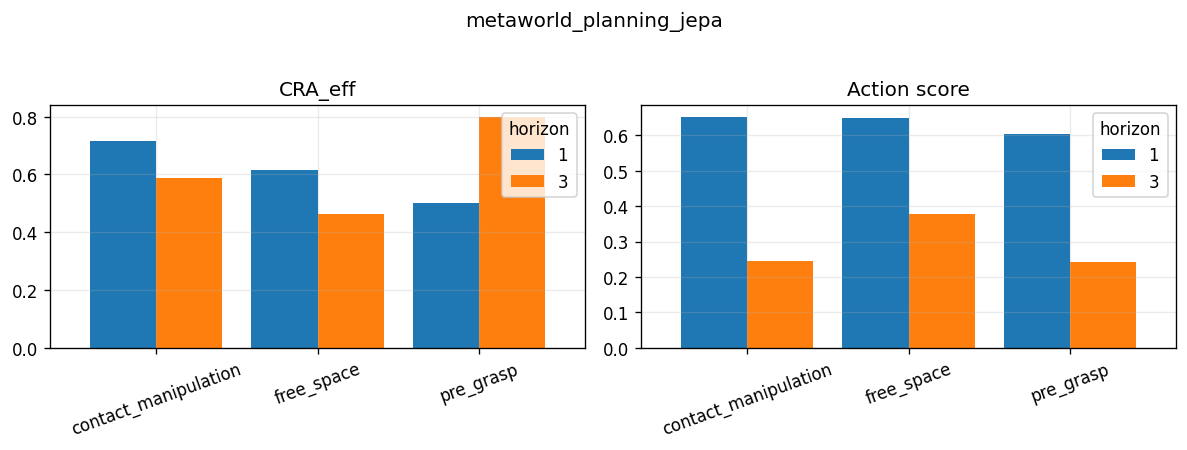

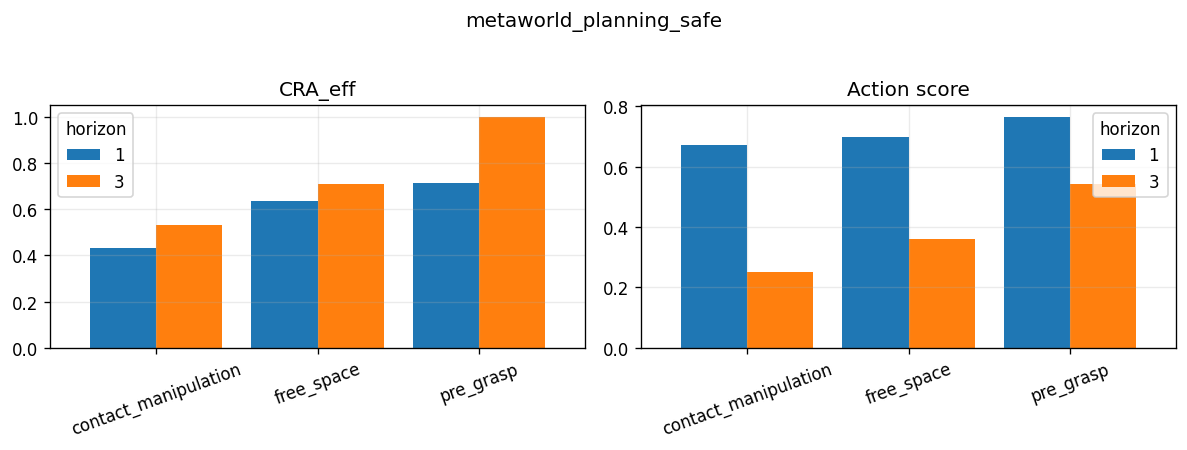

In [4]:
score_tables = {k: v for k, v in summary_tables.items() if {"cra_eff", "action_score"}.issubset(v.columns)}
for name, df in score_tables.items():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=False)
    for ax, col, label in zip(axes, ["cra_eff", "action_score"], ["CRA_eff", "Action score"]):
        piv = df.pivot_table(index="regime", columns="horizon", values=col, aggfunc="mean")
        piv.plot(kind="bar", ax=ax, width=0.82)
        ax.set_title(label)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
    fig.suptitle(name, y=1.03)
    plt.tight_layout()
    plt.show()

if not score_tables:
    print("No planning tables with both cra_eff and action_score were found.")

## 2 · Per-transition planning scatter

loaded 5 per-transition NPZ files
droid_planning_bounded_pertrans            rows= 155 columns=['model', 'regime', 'horizon', 'tid', 'cra_eff_correct', 'action_error']
droid_planning_safe_pertrans               rows= 200 columns=['model', 'regime', 'horizon', 'tid', 'cra_eff_correct', 'action_error']
metaworld_planning_jepa_pertrans           rows=  66 columns=['model', 'regime', 'horizon', 'tid', 'cra_eff_correct', 'action_error']
metaworld_planning_metric_pertrans         rows=  41 columns=['regime', 'tid', 'l2', 'aware', 'obj', 'hdyn']
metaworld_planning_safe_pertrans           rows= 117 columns=['model', 'regime', 'horizon', 'tid', 'cra_eff_correct', 'action_error']


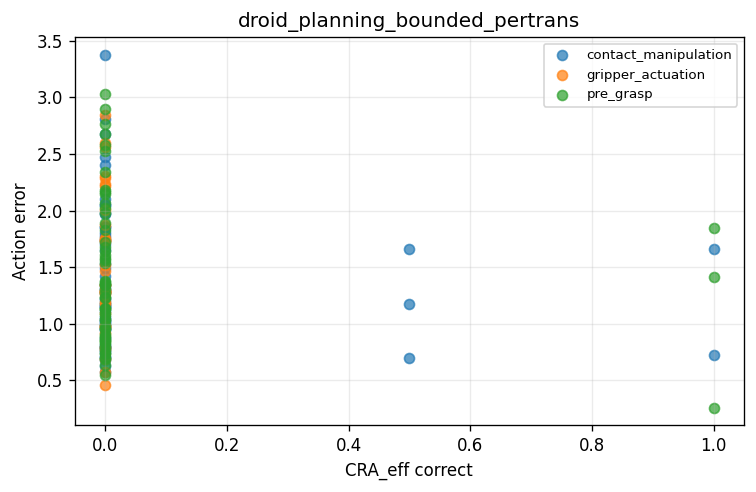

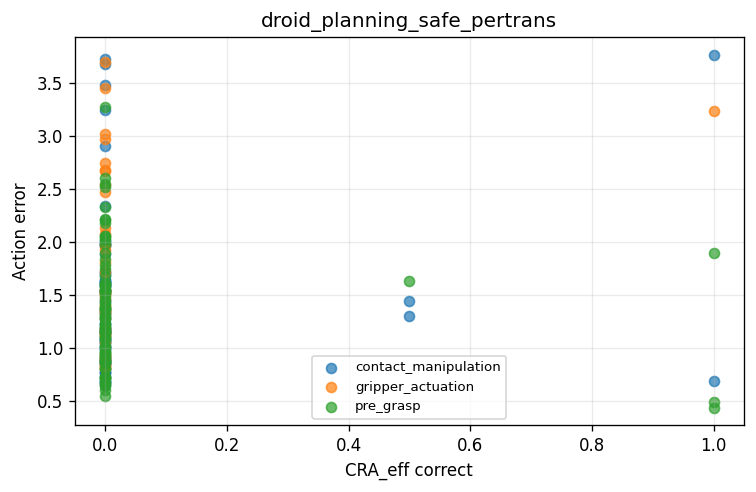

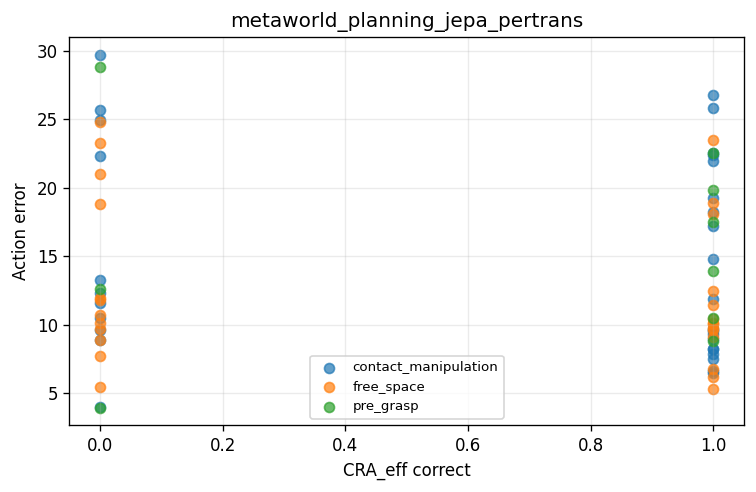

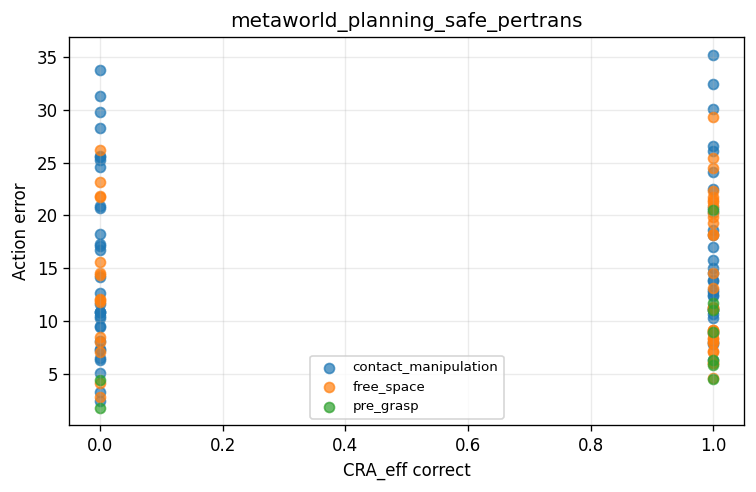

In [5]:
npz_paths = sorted(RESULTS.glob("*planning*_pertrans.npz"))
pertrans = {}
for path in npz_paths:
    try:
        data = np.load(path, allow_pickle=True)
        pertrans[path.stem] = pd.DataFrame({k: data[k] for k in data.files})
    except Exception as exc:
        print(f"skip {path.name}: {exc}")

print(f"loaded {len(pertrans)} per-transition NPZ files")
for name, df in pertrans.items():
    print(f"{name:42s} rows={len(df):4d} columns={list(df.columns)}")

for name, df in pertrans.items():
    if {"cra_eff_correct", "action_error", "regime"}.issubset(df.columns):
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        for regime, sub in df.groupby("regime"):
            ax.scatter(sub["cra_eff_correct"], sub["action_error"], alpha=0.7, label=regime)
        ax.set_title(name)
        ax.set_xlabel("CRA_eff correct")
        ax.set_ylabel("Action error")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

## 3 · Paired metric arms

,dataset,model,regime,horizon,arm,n_planned,beta,s_z,s_g,action_error,action_error_lo,action_error_hi
0,metaworld,dino_wm_metaworld,free_space,3,l2,14,1.0,169.305893,0.127605,18.851582,14.799640,23.166019
1,metaworld,dino_wm_metaworld,free_space,3,aware,14,1.0,169.305893,0.127605,19.157252,15.071599,23.431551
2,metaworld,dino_wm_metaworld,free_space,3,obj,14,1.0,169.305893,0.127605,21.480787,17.312314,26.072625
3,metaworld,dino_wm_metaworld,free_space,3,hdyn,14,1.0,169.305893,0.127605,18.997943,14.815109,23.314156
4,metaworld,dino_wm_metaworld,free_space,3,aware_minus_l2_paired,14,1.0,169.305893,0.127605,0.305670,-0.040778,0.706148
5,metaworld,dino_wm_metaworld,free_space,3,hdyn_minus_l2_paired,14,1.0,169.305893,0.127605,0.146361,-0.150271,0.517251
6,metaworld,dino_wm_metaworld,pre_grasp,3,l2,6,1.0,169.305893,0.127605,15.768547,12.177201,19.514250
7,metaworld,dino_wm_metaworld,pre_grasp,3,aware,6,1.0,169.305893,0.127605,15.874446,12.327159,19.613859
8,metaworld,dino_wm_metaworld,pre_grasp,3,obj,6,1.0,169.305893,0.127605,21.148960,16.654713,25.261740
9,metaworld,dino_wm_metaworld,pre_grasp,3,hdyn,6,1.0,169.305893,0.127605,15.620056,11.806762,19.370352


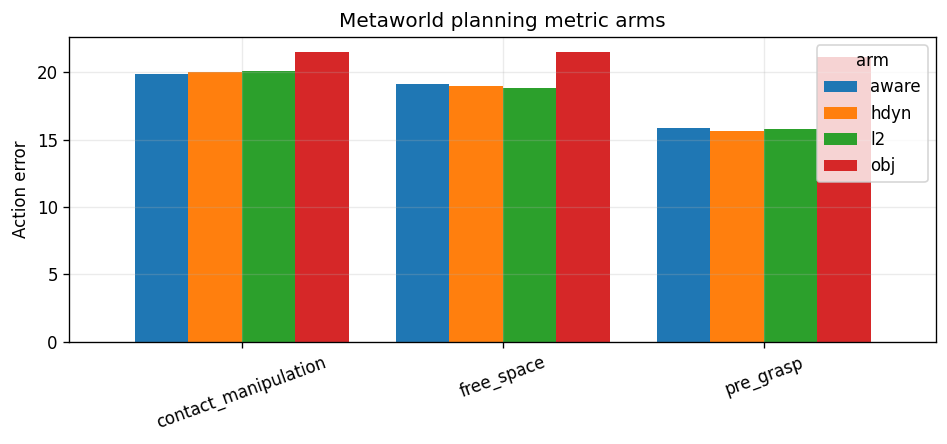

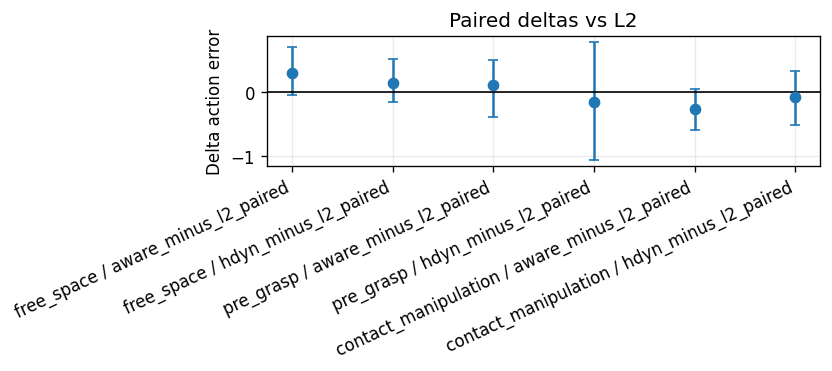

In [6]:
metric_path = RESULTS / "metaworld_planning_metric.csv"
if metric_path.exists():
    metric = pd.read_csv(metric_path)
    display(metric.head(12))
    base = metric[~metric["arm"].astype(str).str.contains("minus", na=False)].copy()
    fig, ax = plt.subplots(figsize=(8, 3.8))
    piv = base.pivot_table(index="regime", columns="arm", values="action_error", aggfunc="mean")
    piv.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title("Metaworld planning metric arms")
    ax.set_ylabel("Action error")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    paired = metric[metric["arm"].astype(str).str.contains("minus", na=False)]
    if len(paired):
        fig, ax = plt.subplots(figsize=(7, 3.2))
        labels = paired["regime"].astype(str) + " / " + paired["arm"].astype(str)
        y = paired["action_error"].to_numpy()
        lo = y - paired["action_error_lo"].to_numpy()
        hi = paired["action_error_hi"].to_numpy() - y
        ax.errorbar(np.arange(len(y)), y, yerr=[lo, hi], fmt="o", capsize=3)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_xticks(np.arange(len(y)), labels, rotation=25, ha="right")
        ax.set_ylabel("Delta action error")
        ax.set_title("Paired deltas vs L2")
        plt.tight_layout()
        plt.show()
else:
    print(f"No metric table at {metric_path}")

## 4 · Faithful CEM trace on one transition

This section loads the real world-model adapter and latent cache. It can take time and requires the configured checkpoint/runtime to be available. If something is missing, the exception is caught so the result-summary plots above remain usable.

In [7]:
def load_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    mod = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(mod)
    return mod

def run_cem_trace():
    import os
    import h5py
    import torch
    import yaml

    from data import LatentCache, read_regimes
    from data.latent_cache import REGIME_TO_ID
    from metrics.action_score import action_error
    from models.adapters import build_adapter
    from planning.cem_planner import cem_plan_trace

    cfg = yaml.safe_load(open(CONFIG_PATH))
    requested_device = DEVICE or cfg.get("eval", {}).get("device", "cpu")
    if requested_device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("DEVICE='cuda' was requested, but CUDA is not available in this kernel.")
    device = torch.device(requested_device)

    cache_root = Path(os.environ.get("CAI_JEPA_LATENT_CACHE_ROOT", cfg["latent_cache"]["root"]))
    if not cache_root.is_absolute():
        cache_root = ROOT / cache_root
    cache_path = cache_root / f"{DATASET}__{MODEL}.h5"
    if not cache_path.exists():
        raise FileNotFoundError(f"latent cache not found: {cache_path}")

    adapter = build_adapter(MODEL, device=str(device)).eval()
    step = adapter.frames_per_step
    raw_A = adapter.spec.action_dim
    model_A = adapter._model_action_dim
    pcfg = cfg.get("planning", {})
    cem_kw = dict(
        num_samples=int(pcfg.get("num_samples", 300)),
        iterations=int(pcfg.get("iterations", 15)),
        num_elites=int(pcfg.get("num_elites", 10)),
        var_scale=float(pcfg.get("var_scale", 0.1)),
        max_norms=list(pcfg.get("max_norms", [1.0])),
        max_norm_dims=[list(g) for g in pcfg.get("max_norm_dims", [list(range(model_A))])],
    )

    helpers = load_module("_runner05", ROOT / "scripts" / "05_run_diagnostic.py")
    probe08 = load_module("_probe08", ROOT / "scripts" / "08_planning_probe.py")
    regime_by_traj = read_regimes(cache_path)

    with LatentCache(cache_path, mode="r") as cache:
        records = helpers.build_transition_records(cache, regime_by_traj, step=step, per_task=False)
        rid = REGIME_TO_ID[REGIME]

        def enough_horizon(record):
            grp = cache.h5["trajectories"][LatentCache._safe_key(record["tid"])]
            return record["idx0"] + HORIZON * step < int(grp["z"].shape[0])

        cell = [r for r in records if r["regime"] == rid and enough_horizon(r)]
        if not cell:
            raise RuntimeError(f"No transitions found for regime={REGIME!r}, horizon={HORIZON}")
        record = cell[int(TRANSITION_INDEX) % len(cell)]
        data = probe08.load_planning_cell(cache, [record], step, HORIZON, want_proprio=adapter.uses_proprio())

    zi = data["z_t"][0].to(device).float()
    zg = data["z_goal"][0].to(device).float()
    p_t = data["proprio_t"][0].to(device).float() if adapter.uses_proprio() and data["proprio_t"][0] is not None else None
    trace = cem_plan_trace(
        adapter, zi, zg, horizon=HORIZON, action_dim=model_A, num_act_stepped=HORIZON,
        proprio_t=p_t, generator=torch.Generator(device=device).manual_seed(1000 + int(TRANSITION_INDEX)),
        **cem_kw,
    )

    plan_raw = trace["plan"].reshape(-1, raw_A).detach().cpu()
    expert_raw = data["expert_raw"][0].detach().cpu()
    err = action_error(plan_raw, expert_raw)
    rollout = adapter.predict_rollout(zi.reshape(1, *zi.shape), trace["plan"].reshape(1, HORIZON, model_A), proprio_t=p_t.reshape(1, -1) if p_t is not None else None)
    latent_dist = ((rollout[:, 1:].reshape(HORIZON, -1) - zg.reshape(1, -1)) ** 2).mean(dim=1).detach().cpu().numpy()

    return {
        "trace": trace,
        "record": record,
        "n_candidates": len(cell),
        "plan_raw": plan_raw.numpy(),
        "expert_raw": expert_raw.numpy(),
        "action_error": err,
        "latent_dist_to_goal": latent_dist,
        "cem_kw": cem_kw,
        "step": step,
        "raw_A": raw_A,
        "model_A": model_A,
    }

try:
    trace_out = run_cem_trace()
    print("trace ready")
    print("record:", trace_out["record"])
    print("available candidates in selected cell:", trace_out["n_candidates"])
    print("cem:", trace_out["cem_kw"])
    print("action error:", trace_out["action_error"])
except Exception as exc:
    trace_out = None
    print("CEM trace skipped:", exc)

CEM trace skipped: DEVICE='cuda' was requested, but CUDA is not available in this kernel.


## 5 · Trace diagnostics

In [8]:
if trace_out is None:
    print("No trace to plot. Check the message in the previous cell.")
else:
    trace_rows = []
    for row in trace_out["trace"]["trace"]:
        trace_rows.append({
            "iteration": row["iteration"],
            "best_cost": float(row["best_cost"]),
            "mean_cost": float(row["mean_cost"]),
            "median_cost": float(row["median_cost"]),
            "elite_min_cost": float(row["elite_min_cost"]),
            "elite_max_cost": float(row["elite_max_cost"]),
            "clip_fraction": float(row["clip_fraction"]),
            "action_norm_mean": float(row["action_norm_mean"]),
            "elite_action_norm_mean": float(row["elite_action_norm_mean"]),
        })
    trace_df = pd.DataFrame(trace_rows)
    display(trace_df)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    axes[0].plot(trace_df["iteration"], trace_df["best_cost"], marker="o", label="best")
    axes[0].plot(trace_df["iteration"], trace_df["median_cost"], marker="o", label="median")
    axes[0].fill_between(trace_df["iteration"], trace_df["elite_min_cost"], trace_df["elite_max_cost"], alpha=0.2, label="elite range")
    axes[0].set_title("Cost convergence")
    axes[0].set_xlabel("CEM iteration")
    axes[0].set_ylabel("Cost")
    axes[0].legend(fontsize=8)

    axes[1].plot(trace_df["iteration"], trace_df["clip_fraction"], marker="o")
    axes[1].set_title("Clip saturation")
    axes[1].set_xlabel("CEM iteration")
    axes[1].set_ylabel("Fraction clipped")

    axes[2].plot(trace_df["iteration"], trace_df["action_norm_mean"], marker="o", label="population")
    axes[2].plot(trace_df["iteration"], trace_df["elite_action_norm_mean"], marker="o", label="elite")
    axes[2].set_title("Action norm")
    axes[2].set_xlabel("CEM iteration")
    axes[2].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

No trace to plot. Check the message in the previous cell.


In [9]:
if trace_out is None:
    print("No trace to plot.")
else:
    final_mean = trace_out["trace"]["final_mean"].numpy()
    final_std = trace_out["trace"]["final_std"].numpy()
    best_last = trace_out["trace"]["trace"][-1]["best_action"].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, mat, title in zip(axes, [final_mean, final_std, best_last], ["Final CEM mean", "Final CEM std", "Best sampled action"]):
        im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
        ax.set_title(title)
        ax.set_xlabel("Action dim")
        ax.set_ylabel("Horizon step")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    plan = trace_out["plan_raw"]
    expert = trace_out["expert_raw"]
    T = min(len(plan), len(expert))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].plot(plan[:T], marker="o")
    axes[0].set_title("Planned raw actions")
    axes[0].set_xlabel("Raw action step")
    axes[0].set_ylabel("Action value")
    axes[1].plot(expert[:T], marker="o")
    axes[1].set_title("Expert raw actions")
    axes[1].set_xlabel("Raw action step")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.plot(np.arange(1, len(trace_out["latent_dist_to_goal"]) + 1), trace_out["latent_dist_to_goal"], marker="o")
    ax.set_title("Final plan rollout distance to goal")
    ax.set_xlabel("Rollout step")
    ax.set_ylabel("MSE to goal latent")
    plt.tight_layout()
    plt.show()

No trace to plot.
